In [1]:
# ensure classes imported from .py files are dynamically updated
%load_ext autoreload
%autoreload 2

# plot matplots nicely
%matplotlib inline  

In [2]:
from stericheight.data_handler import *
from stericheight.steric_height import *
from stericheight.plotting_fns import PlottingFns
from region import Region
from functions import Functions
pfns = PlottingFns()
fns = Functions()

In [3]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cmocean
from cartopy.feature import LAND
from gsw import conversions, density
from glob import glob
from OceanDataStore import OceanDataCatalog


In [5]:
catalog = OceanDataCatalog(catalog_name="noc-model-stac")
ds4 = catalog.open_dataset(id='noc-npd-era5/npd-eorca025-era5v1/gn/T1m_4d',
                           variable_names=['thetao_con','so_abs'],
                          )
ds3 = catalog.open_dataset(id='noc-npd-era5/npd-eorca12-era5v1/gn/T1m_3d',variable_names=['zos'])

ValueError: Unsupported media type application/vnd.zarr+icechunk for Item asset.

In [ ]:
dsu = catalog.open_dataset(id='noc-npd-era5/npd-eorca12-era5v1/gn/U1m_4d',variable_names=['uo'])
dsv = catalog.open_dataset(id='noc-npd-era5/npd-eorca12-era5v1/gn/V1m_4d',variable_names=['uo'])

NameError: name 'catalog' is not defined

In [11]:
gyre_index = xr.open_dataarray('gyre_index_nemo.nc')

In [12]:
sla_ = SLA(deg=0.25).da

minla = -68
maxla = -63

extent_ac = [138,152,minla,maxla]
extent_ea=[60,160,-70,-60]


In [32]:
ds = xr.merge([ds3,ds4])

/tmp/ipykernel_1071847/3022806531.py:1: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge([ds3,ds4])
/tmp/ipykernel_1071847/3022806531.py:1: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds = xr.merge([ds3,ds4])
/tmp/ipykernel_1071847/3022806531.py:1: FutureWarning: In a future version of xarray the default value for compat 

In [34]:
# prepare nemo
def prep_nemo(ds_in,t_lims,lat_lims,lon_lims):
    # crop to time & make monthly
    ds_renamed = ds_in.rename({'time_counter':'time'})
    ds_cropped = ds_renamed.sel(time=slice(t_lims[0],t_lims[1])).resample({'time':'MS'}).mean()

    # crop to region
    lats = ds_cropped.nav_lat.load()
    lons = ds_cropped.nav_lon.load()

    mask = (lats >= lat_lims[0]) & (lats <= lat_lims[1]) & (lons >= lon_lims[0]) & (lons <= lon_lims[1])

    return ds_cropped.where(mask,drop=True)

In [ ]:
nemo4 = prep_nemo(ds,[sla_.time[0],sla_.time[-1]],[minla,maxla],[extent_ac[0],extent_ac[1]])

In [38]:
nemo4.load()

<xarray.Dataset> Size: 3GB
Dimensions:     (time: 227, y: 146, x: 169, deptht: 75)
Coordinates:
  * time        (time) datetime64[ns] 2kB 2003-01-01 2003-02-01 ... 2021-11-01
  * y           (y) int64 1kB 915 916 917 918 919 ... 1056 1057 1058 1059 1060
  * x           (x) int64 1kB 780 781 782 783 784 785 ... 944 945 946 947 948
  * deptht      (deptht) float32 300B 0.5058 1.556 2.668 ... 5.698e+03 5.902e+03
    nav_lon     (y, x) float64 197kB 138.0 138.1 138.2 ... 151.8 151.9 152.0
    nav_lat     (y, x) float64 197kB -67.99 -67.99 -67.99 ... -63.0 -63.0 -63.0
Data variables:
    zos         (time, y, x) float32 22MB nan nan nan ... -1.741 -1.741 -1.741
    thetao_con  (time, deptht, y, x) float32 2GB nan nan nan nan ... nan nan nan
    so_abs      (time, deptht, y, x) float32 2GB nan nan nan nan ... nan nan nan
Attributes:
    name:         OUTPUT/eORCA12_1m_grid_T
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2025-Jul-22 16:19:04 GMT
    uuid:         61cea34a-0d4b-42be-bb07-aebe2e46e60f

In [40]:
# create a slice
lonslice = [144.5,145.5]
lons = nemo4.nav_lon.load()
lonmask = (lons >= lonslice[0]) & (lons <= lonslice[1])

nemo3 = nemo4.where(lonmask,drop=True).mean('x')

In [41]:
# compute density etc
def calc_vars(ds):
    ds['pressure'] = conversions.p_from_z(ds.deptht,ds.y.mean())
    ds['rho'] = density.rho(ds.so_abs,ds.thetao_con,ds.pressure)
    ds['sigma0'] = density.sigma0(ds.so_abs,ds.thetao_con)

calc_vars(nemo4)
calc_vars(nemo3)

In [43]:
sla = nemo4.zos

In [44]:
u,v = fns.get_geostrophic_currents(sla,lat_name='y',lon_name='x')
geos = xr.Dataset({'u10':u,'v10':v})

In [ ]:
# prepare other data
sa_sla = fns.seasonal_anomaly(sla)
sa_geos = fns.seasonal_anomaly(geos)
sa_gyre = fns.seasonal_anomaly(gyre_index)
sa_nemo = fns.seasonal_anomaly(nemo4)
sa_nemo_slice = fns.seasonal_anomaly(nemo3)


In [ ]:
# store data for fast loading
fldr = '../data/nemo_transect_processing/'

nemo4.to_netcdf(fldr+'nemo4.nc')
nemo3.to_netcdf(fldr+'nemo3.nc')

sa_sla.to_netcdf(fldr+'sa_sla.nc')
sa_geos.to_netcdf(fldr+'sa_geos.nc')
sa_gyre.to_netcdf(fldr+'sa_gyre.nc')
sa_nemo.to_netcdf(fldr+'sa_nemo4.nc')
sa_nemo_slice.to_netcdf(fldr+'sa_nemo3.nc')

# ssn_sla.to_netcdf(fldr+'ssn_sla.nc')
# ssn_geos.to_netcdf(fldr+'ssn_geos.nc')
# ssn_gyre.to_netcdf(fldr+'ssn_gyre.nc')
# ssn_nemo.to_netcdf(fldr+'ssn_nemo4.nc')
# ssn_nemo_slice.to_netcdf(fldr+'ssn_nemo3.nc')

AttributeError: 'dict' object has no attribute 'to_netcdf'

In [6]:
# load pre-processed data
fldr = '../data/nemo_transect_processing/'

nemo4 = xr.open_dataset(fldr + 'nemo4.nc')
nemo3 = xr.open_dataset(fldr + 'nemo3.nc')

In [7]:
sa_sla = xr.open_dataarray(fldr + 'sa_sla.nc')
sa_geos = xr.open_dataset(fldr + 'sa_geos.nc')
sa_gyre = xr.open_dataarray(fldr + 'sa_gyre.nc')
sa_nemo4 = xr.open_dataset(fldr + 'sa_nemo4.nc')
sa_nemo3 = xr.open_dataset(fldr + 'sa_nemo3.nc')


In [ ]:
ssn_gyre = fns.season_split(sa_gyre)
ssn_sla = fns.season_split(sa_sla)
ssn_geos = fns.season_split(sa_geos)
ssn_nemo4 = fns.season_split(sa_nemo4)
ssn_nemo3 = fns.season_split(sa_nemo3)

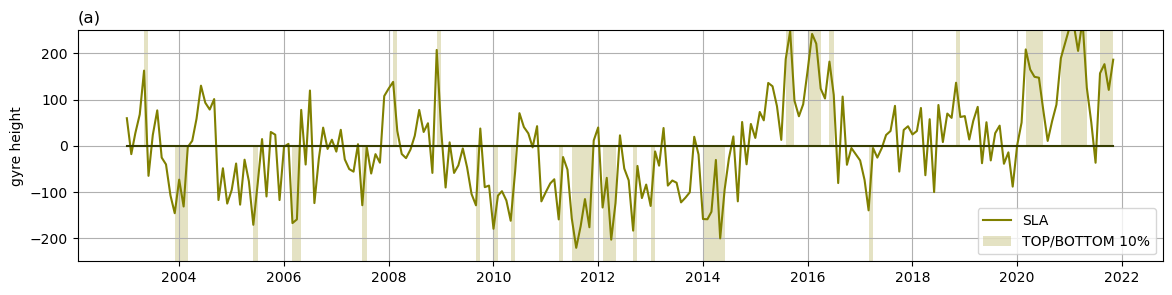

In [8]:
s = 'autumn'
lag=0
frac=0.1

topboo, botboo, top, bot = fns.get_topbot(sa_gyre,frac)
fns.idx_ts(sa_gyre,frac,lag=lag,ylim_idx=250)


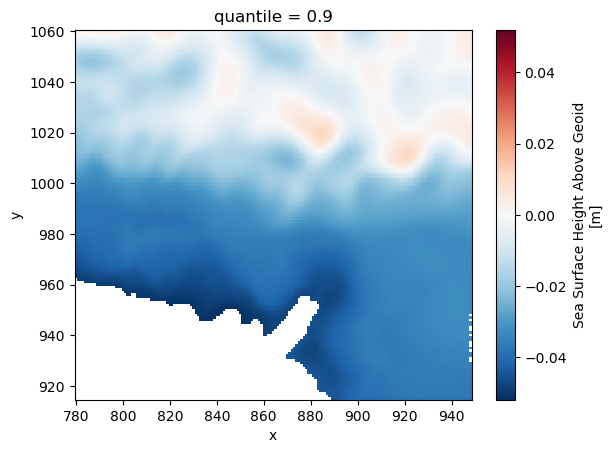

In [9]:
top(sa_sla).plot()

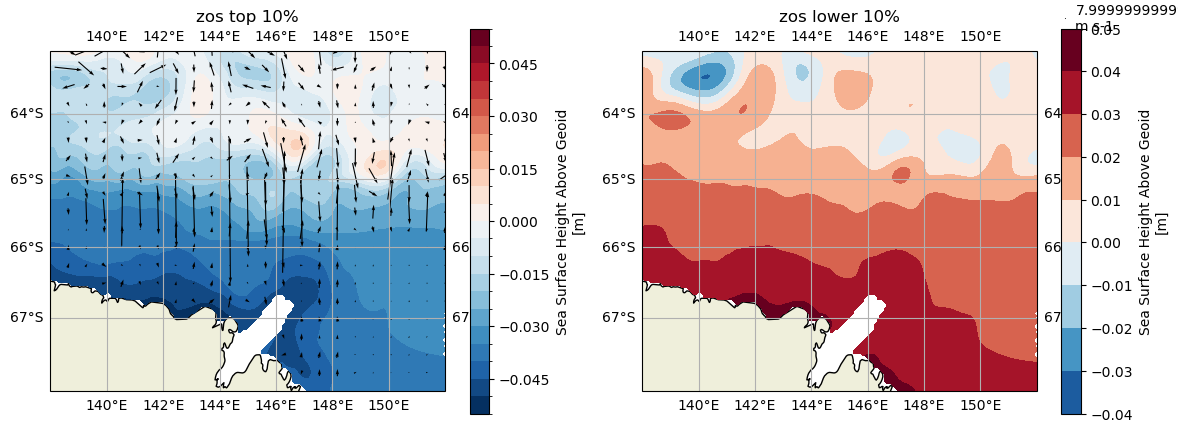

In [13]:
fig,axs=plt.subplots(1,2,figsize=(14,5),subplot_kw={'projection':ccrs.Mercator()})

ax=axs[0]
top(sa_sla).plot.contourf(ax=ax,x='nav_lon',y='nav_lat',transform=ccrs.PlateCarree(),levels=25)
top(sa_geos).plot.quiver(ax=ax,x='nav_lon',y='nav_lat',u='u10', v='v10',transform=ccrs.PlateCarree(),regrid_shape=20)
ax.set_title('zos top 10%')
ax.set_extent(extent_ac,crs=ccrs.PlateCarree())
ax.add_feature(LAND, edgecolor='k')
ax.gridlines(draw_labels=True)

ax=axs[1]
bot(sa_sla).plot.contourf(ax=ax,x='nav_lon',y='nav_lat',transform=ccrs.PlateCarree())
ax.set_title('zos lower 10%')
ax.set_extent(extent_ac,crs=ccrs.PlateCarree())
ax.add_feature(LAND, edgecolor='k')
ax.gridlines(draw_labels=True)

In [15]:
tops = top(sa_nemo3,lag)#ssn_sose[s],lag)
bots = bot(sa_nemo3,lag)#ssn_sose[s],lag)

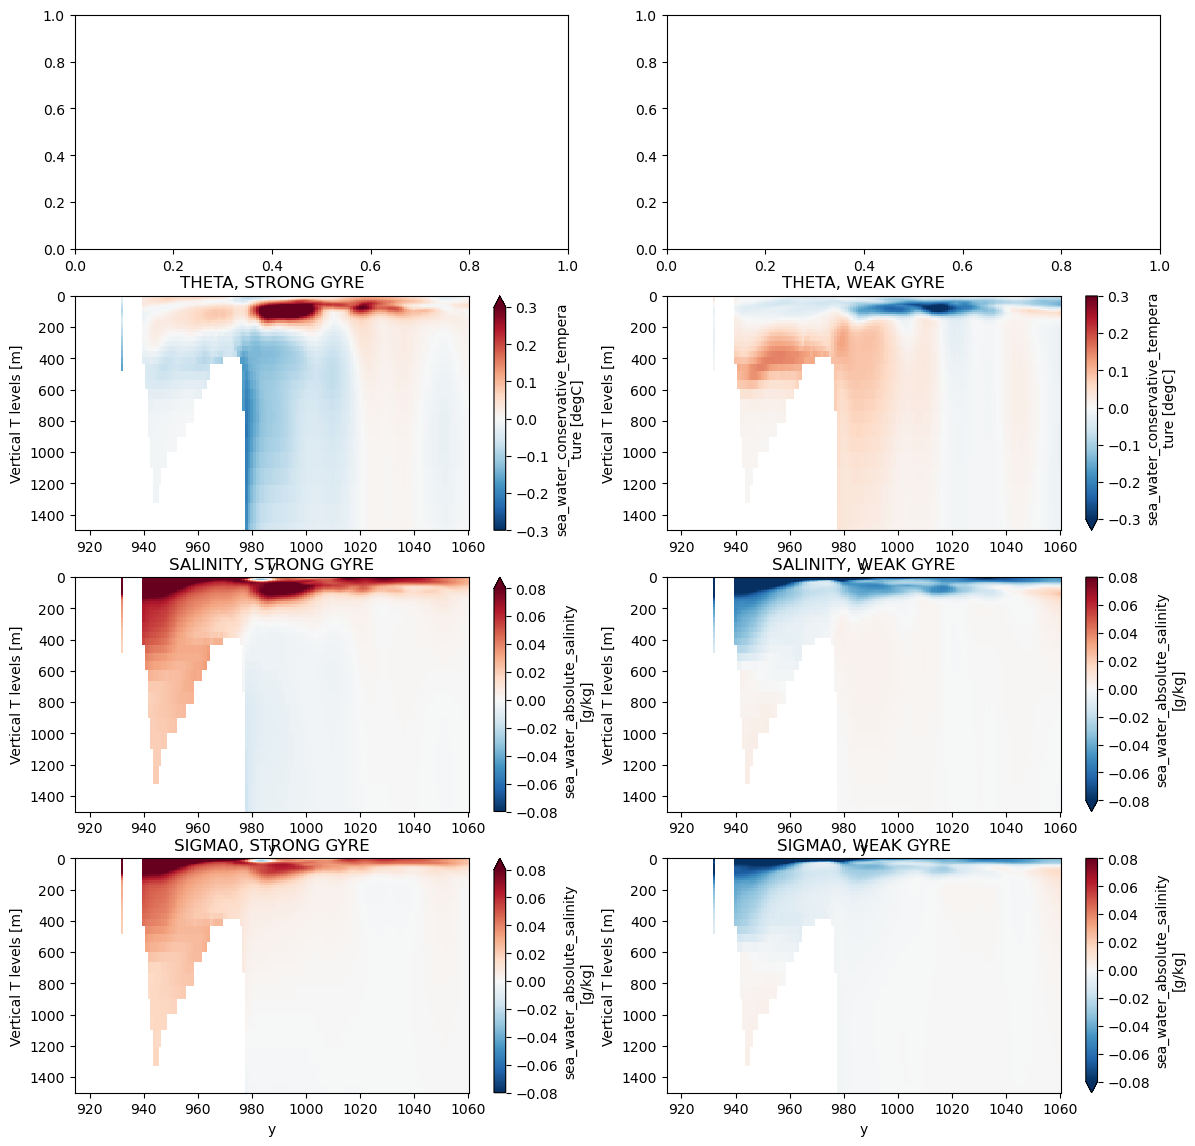

In [16]:
fig,axs = plt.subplots(4,2,figsize=(14,14))

ax = axs[0]
# tops.SIarea.plot(ax=ax[0])
# ax[0].set_title('SEA ICE AREA, STRONG GYRE')
# ax[0].set_ylim([-0.1,0.2])

# bots.SIarea.plot(ax=ax[1])
# ax[1].set_title('SEA ICE AREA, WEAK GYRE')
# ax[1].set_ylim([-0.1,0.2])

z = 1500

def plot_transect(data,ax,title,vmin):
    data.plot(ax=ax,vmin=vmin)
    ax.set_title(title)
    ax.set_ylim([0,z])
    ax.invert_yaxis()

    #ax.set_xlim([-67.5,-64.5])

ax = axs[1]
plot_transect(tops.thetao_con,ax[0],'THETA, STRONG GYRE',-0.3)
plot_transect(bots.thetao_con,ax[1],'THETA, WEAK GYRE',-0.3)

ax = axs[2]
plot_transect(tops.so_abs,ax[0],'SALINITY, STRONG GYRE',-0.08)
plot_transect(bots.so_abs,ax[1],'SALINITY, WEAK GYRE',-0.08)

ax = axs[3]
plot_transect(tops.sigma0,ax[0],'SIGMA0, STRONG GYRE',-0.08)
plot_transect(bots.sigma0,ax[1],'SIGMA0, WEAK GYRE',-0.08)


In [62]:
nemo3

<xarray.Dataset> Size: 60MB
Dimensions:     (time: 227, y: 146, deptht: 75)
Coordinates:
  * time        (time) datetime64[ns] 2kB 2003-01-01 2003-02-01 ... 2021-11-01
  * y           (y) int64 1kB 915 916 917 918 919 ... 1056 1057 1058 1059 1060
  * deptht      (deptht) float32 300B 0.5058 1.556 2.668 ... 5.698e+03 5.902e+03
Data variables:
    zos         (time, y) float32 133kB nan nan nan nan ... -1.626 -1.62 -1.615
    thetao_con  (time, deptht, y) float32 10MB nan nan nan nan ... nan nan nan
    so_abs      (time, deptht, y) float32 10MB nan nan nan nan ... nan nan nan
    pressure    (deptht) float64 600B -0.5112 -1.573 -2.697 ... nan nan nan
    rho         (time, deptht, y) float64 20MB nan nan nan nan ... nan nan nan
    sigma0      (time, deptht, y) float64 20MB nan nan nan nan ... nan nan nan
Attributes:
    name:         OUTPUT/eORCA12_1m_grid_T
    description:  ocean T grid variables
    title:        ocean T grid variables
    Conventions:  CF-1.6
    timeStamp:    2025-Jul-22 16:19:04 GMT
    uuid:         61cea34a-0d4b-42be-bb07-aebe2e46e60f

In [61]:
def get_xht(ds):
    ds['thetav'] = ds.theto_con.interp({'YC':ds.YG})
    ds['thetavvel'] = ds.thetav * ds.VVEL
    ds['xht'] = -ds.thetavvel.integrate('Z')

xhtl = 'Northward Cross-Shelf Heat Transport'

In [60]:
get_xht(nemo3)

AttributeError: 'Dataset' object has no attribute 'THETA'

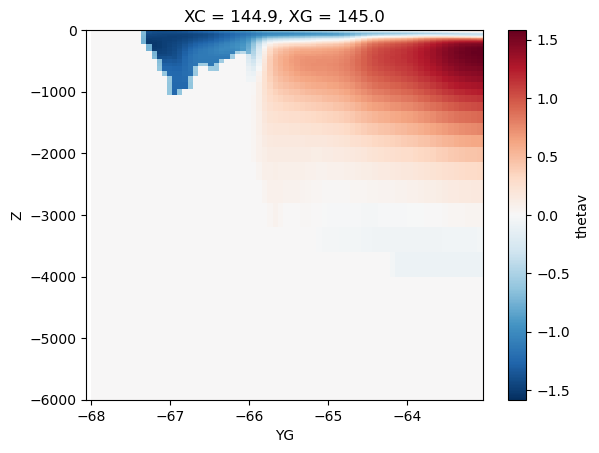

In [48]:
ds145.thetav.mean('time').plot()


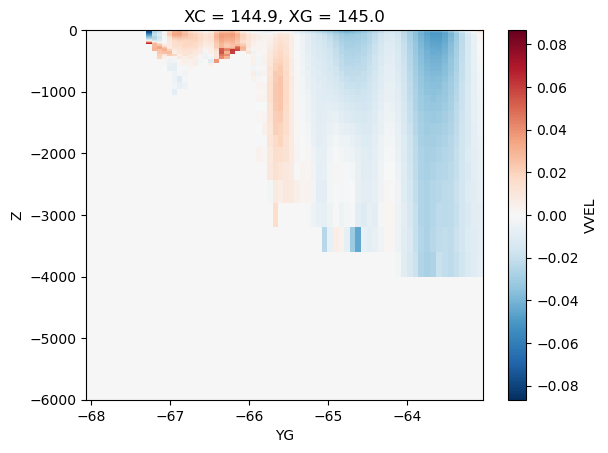

In [49]:
ds145.VVEL.mean('time').plot()


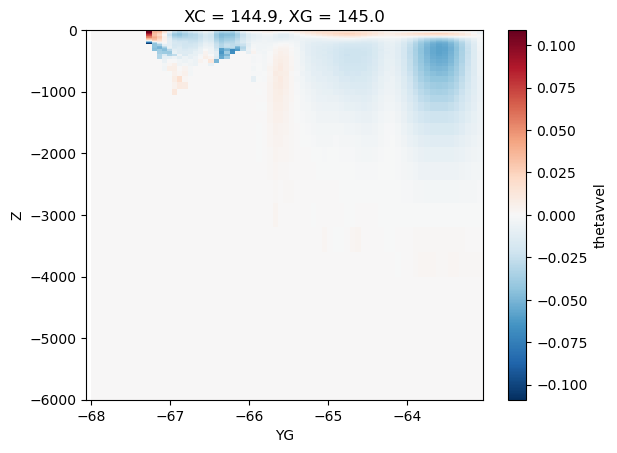

In [47]:
ds145.thetavvel.mean('time').plot()


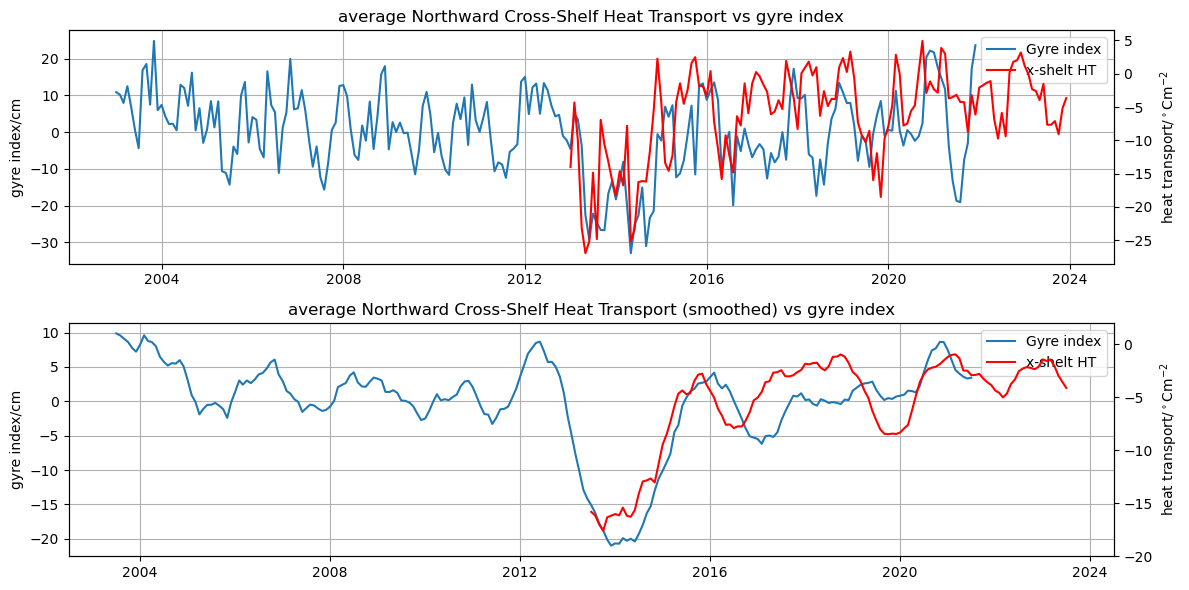

In [40]:
#repeat for l
dsl = ds145.sel(YG=slice(-67,-65)).mean('YG')#,method='nearest')

fig,axs = plt.subplots(2,1,figsize=(12,6))
ax=axs[0]
ax2=ax.twinx()
l1 = ax.plot(gyre_index.time,gyre_index)
l2 = ax2.plot(dsl.time,dsl.xht,c='r')
ax.legend([l1[0],l2[0]],['Gyre index','x-shelt HT'])
ax.grid()
ax2.set_ylabel(r'heat transport/$^\circ$Cm$^{-2}$')
ax.set_ylabel('gyre index/cm')
ax.set_title('average ' + xhtl + ' vs gyre index')

ax=axs[1]
ax2=ax.twinx()
l1=ax.plot(gyre_index.time,gyre_index.rolling({'time':12},center=True).mean())
l2=ax2.plot(dsl.time,dsl.xht.rolling({'time':12},center=True).mean(),c='r')
ax.legend([l1[0],l2[0]],['Gyre index','x-shelt HT'])
ax.grid()
ax2.set_ylabel(r'heat transport/$^\circ$Cm$^{-2}$')
ax.set_ylabel('gyre index/cm')
ax.set_title('average ' + xhtl + ' (smoothed) vs gyre index')
ax2.set_ylim([-20,2])

plt.tight_layout()



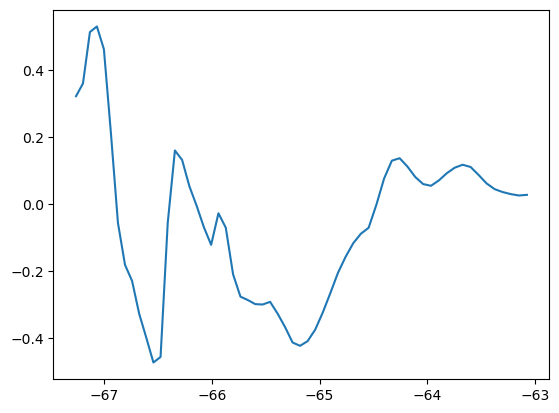

In [86]:
plt.plot(ds145.YG,corr)

In [85]:
corr=[]
maxl=0
gic = gyre_index.sel(time=slice(ds145.xht.time[0],gyre_index.time[-1]))
dsc = ds145.sel(time=slice(ds145.xht.time[0],gyre_index.time[-1]))
for yg in dsc.YG:
    dsyg = dsc.sel(YG=yg)
    xhtyg = dsyg.thetavvel.integrate('Z')
    cc = xr.corr(gic,xhtyg)
    corr.append(cc.item())
    

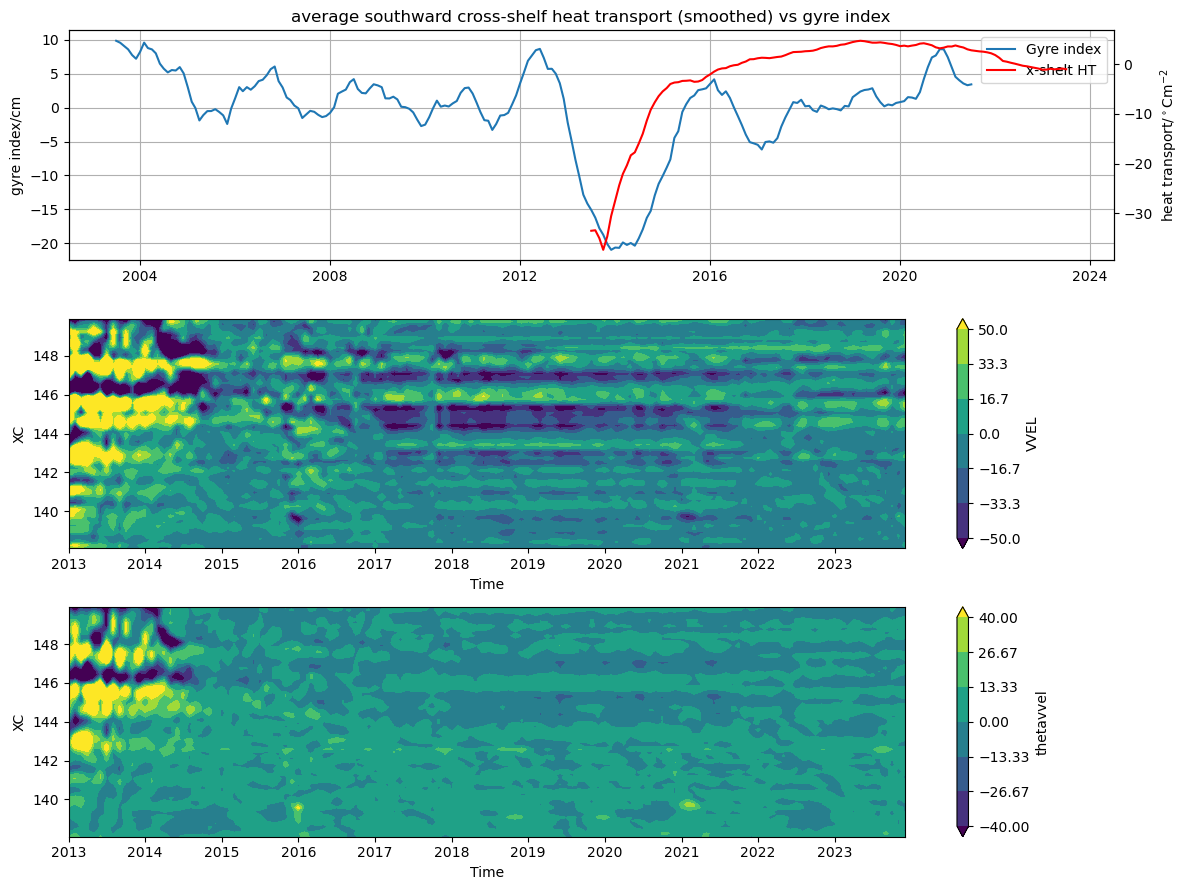

In [19]:
dsm = dsseg.mean('YG')


fig,axs = plt.subplots(3,1,figsize=(12,9))
ax=axs[0]
ax2=ax.twinx()
l1=ax.plot(gyre_index.time,gyre_index.rolling({'time':12},center=True).mean())
l2=ax2.plot(dsm.time,dsm.sel(XC=slice(144,146)).mean('XC').xht.rolling({'time':12},center=True).mean(),c='r')
ax.legend([l1[0],l2[0]],['Gyre index','x-shelt HT'])
ax.grid()
ax2.set_ylabel(r'heat transport/$^\circ$Cm$^{-2}$')
ax.set_ylabel('gyre index/cm')
ax.set_title('average southward cross-shelf heat transport (smoothed) vs gyre index')

ax=axs[1]
dsm.VVEL.integrate('Z').plot.contourf(ax=ax,x='time',y='XC',vmin=-50,vmax=50)

ax=axs[2]
dsm.thetavvel.integrate('Z').plot.contourf(ax=ax,x='time',y='XC',vmin=-40,vmax=40)


plt.tight_layout()

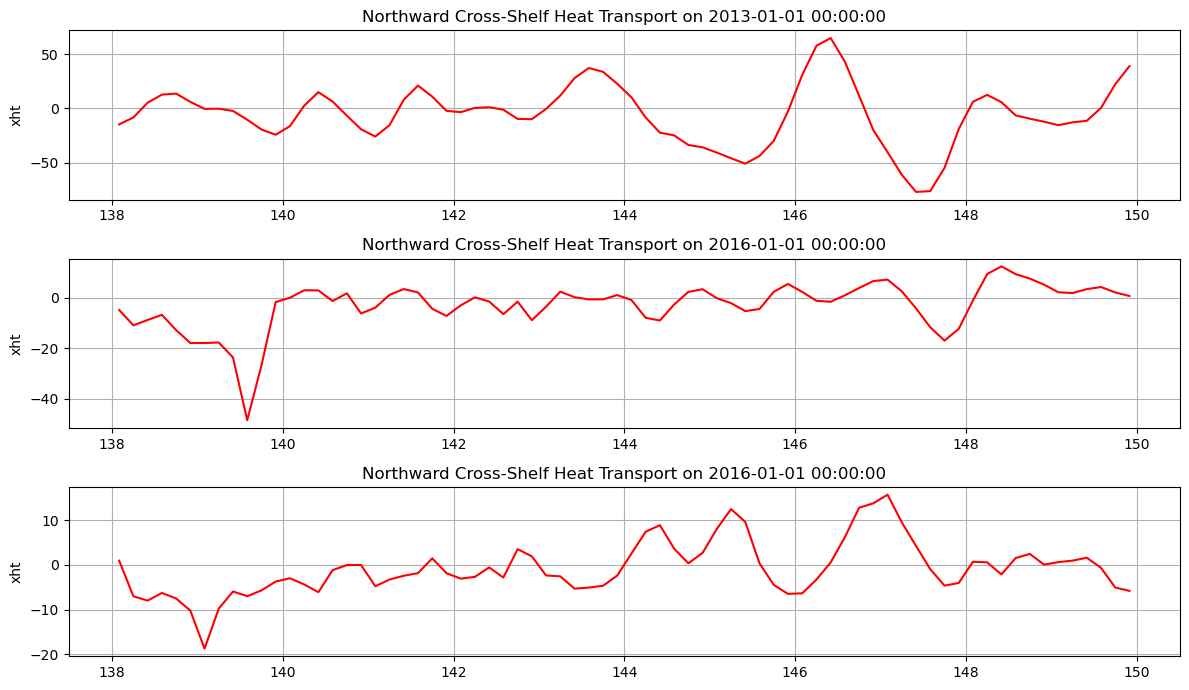

In [50]:
dsm = dsseg.mean('YG')


fig,axs = plt.subplots(3,1,figsize=(12,7))

t1 = pd.Timestamp(2013,1,1)
t2 = pd.Timestamp(2016,1,1)
t3 = pd.Timestamp(2020,1,1)

ax=axs[0]
ax.plot(dsm.XC,dsm.sel(time=t1).xht,c='r')
ax.grid()
ax.set_ylabel('xht')
ax.set_title(xhtl + ' on ' + str(t1))

ax=axs[1]
ax.plot(dsm.XC,dsm.sel(time=t2).xht,c='r')
ax.grid()
ax.set_ylabel('xht')
ax.set_title(xhtl + ' on ' + str(t2))

ax=axs[2]
ax.plot(dsm.XC,dsm.sel(time=t3).xht,c='r')
ax.grid()
ax.set_ylabel('xht')
ax.set_title(xhtl + ' on ' + str(t2))

plt.tight_layout()


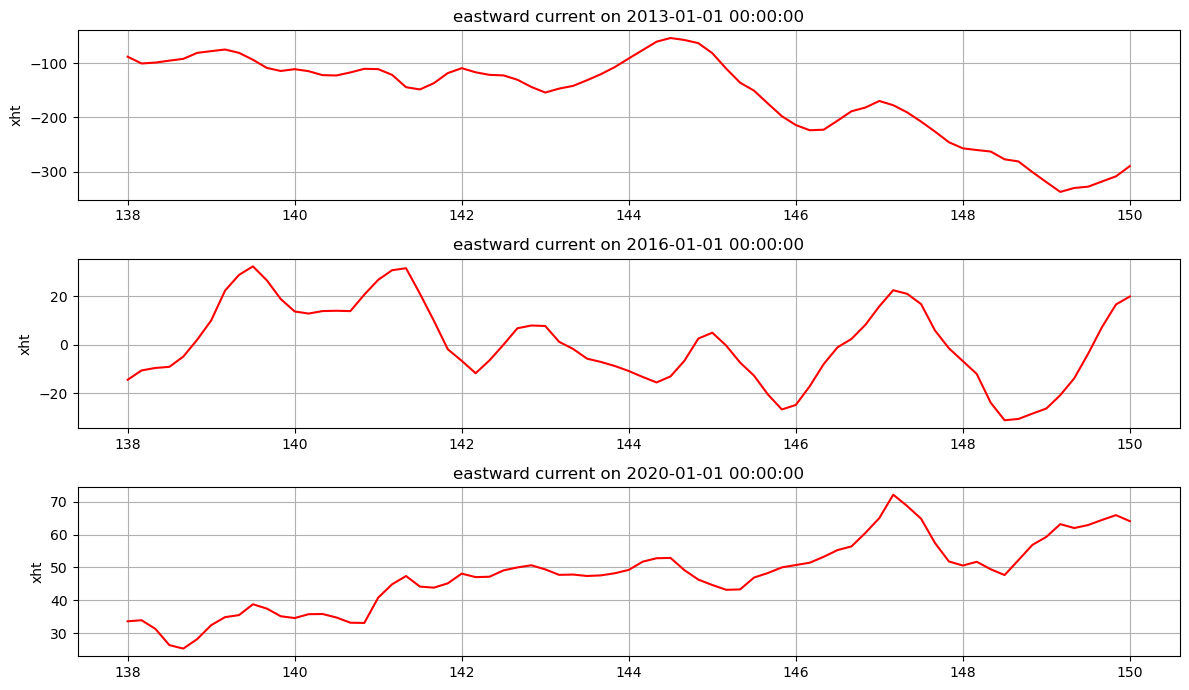

In [61]:
dsm = dsseg.mean('YC')


fig,axs = plt.subplots(3,1,figsize=(12,7))

t1 = pd.Timestamp(2013,1,1)
t2 = pd.Timestamp(2016,1,1)
t3 = pd.Timestamp(2020,1,1)

xhtl = 'eastward current'
ax=axs[0]
ax.plot(dsm.XG,dsm.sel(time=t1).UVEL.integrate('Z'),c='r')
ax.grid()
ax.set_ylabel('xht')
ax.set_title(xhtl + ' on ' + str(t1))

ax=axs[1]
ax.plot(dsm.XG,dsm.sel(time=t2).UVEL.integrate('Z'),c='r')
ax.grid()
ax.set_ylabel('xht')
ax.set_title(xhtl + ' on ' + str(t2))

ax=axs[2]
ax.plot(dsm.XG,dsm.sel(time=t3).UVEL.integrate('Z'),c='r')
ax.grid()
ax.set_ylabel('xht')
ax.set_title(xhtl + ' on ' + str(t3))

plt.tight_layout()

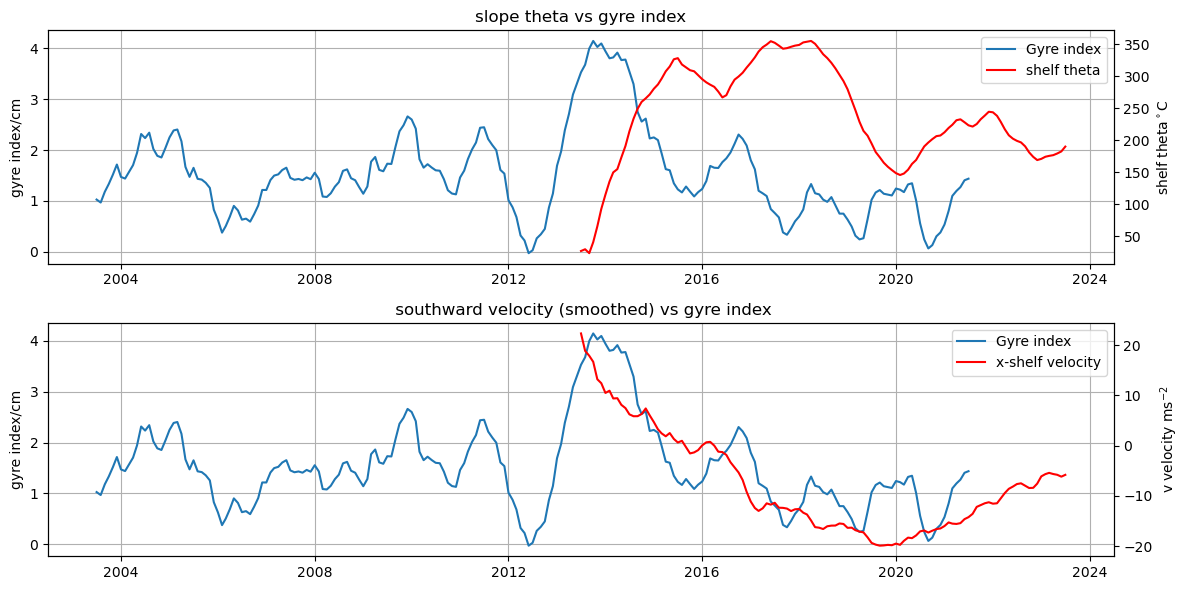

In [18]:
fig,axs = plt.subplots(2,1,figsize=(12,6))
ax=axs[0]
l1 = ax.plot(gyre_index.time,gyre_index.rolling({'time':12},center=True).mean())
ax2=ax.twinx()
l2 = ax2.plot(ds.time,ds.thetav.integrate('Z').mean('YG').rolling({'time':12},center=True).mean(),c='r')
ax.legend([l1[0],l2[0]],['Gyre index','shelf theta'])
ax.grid()
ax2.set_ylabel(r'shelf theta$^\circ$C')
ax.set_ylabel('gyre index/cm')
ax.set_title('slope theta vs gyre index')

ax=axs[1]
ax2=ax.twinx()
l1=ax.plot(gyre_index.time,gyre_index.rolling({'time':12},center=True).mean())
l2=ax2.plot(ds.time,ds.VVEL.integrate('Z').mean('YG').rolling({'time':12},center=True).mean(),c='r')
ax.legend([l1[0],l2[0]],['Gyre index','x-shelf velocity'])
ax.grid()
ax2.set_ylabel(r'v velocity ms$^{-2}$')
ax.set_ylabel('gyre index/cm')
ax.set_title(' southward velocity (smoothed) vs gyre index')

plt.tight_layout()

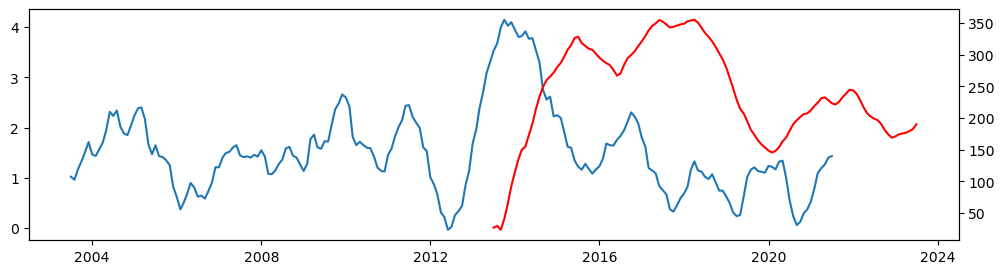

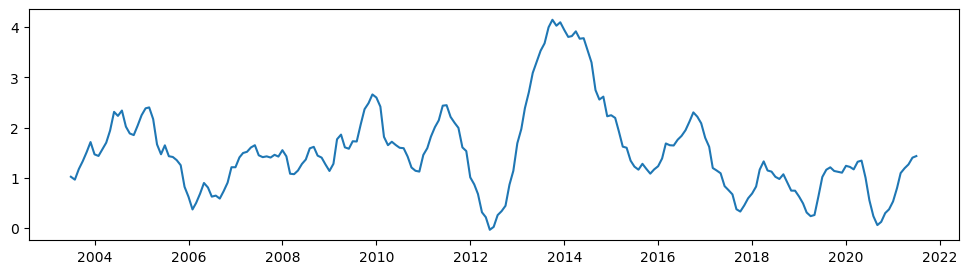

In [19]:

fig,ax = plt.subplots(figsize=(12,3))
ax.plot(gyre_index.time,gyre_index.rolling({'time':12},center=True).mean())
ax.twinx().plot(ds.time,ds.thetav.integrate('Z').mean('YG').rolling({'time':12},center=True).mean(),c='r')

fig,ax = plt.subplots(figsize=(12,3))
ax.plot(gyre_index.time,gyre_index.rolling({'time':12},center=True).mean())


In [20]:
s_sigma = fns.season_split(ds.sigma0)
s_theta = fns.season_split(ds.THETA)
s_salty = fns.season_split(ds.SALT)


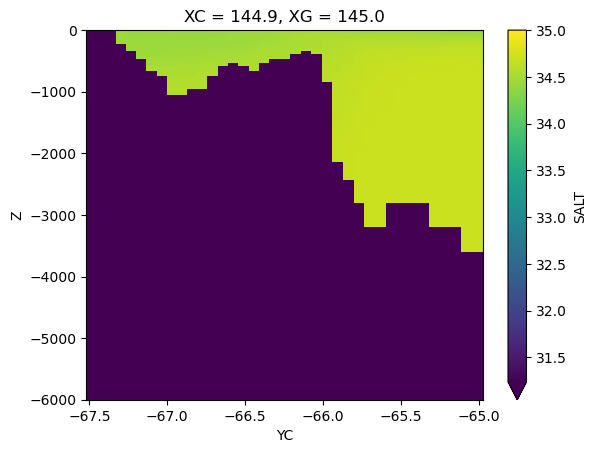

In [21]:
s_salty['spring'].mean('time').plot(vmin=35)

In [22]:
dss = fns.season_split(ds.sigma0)

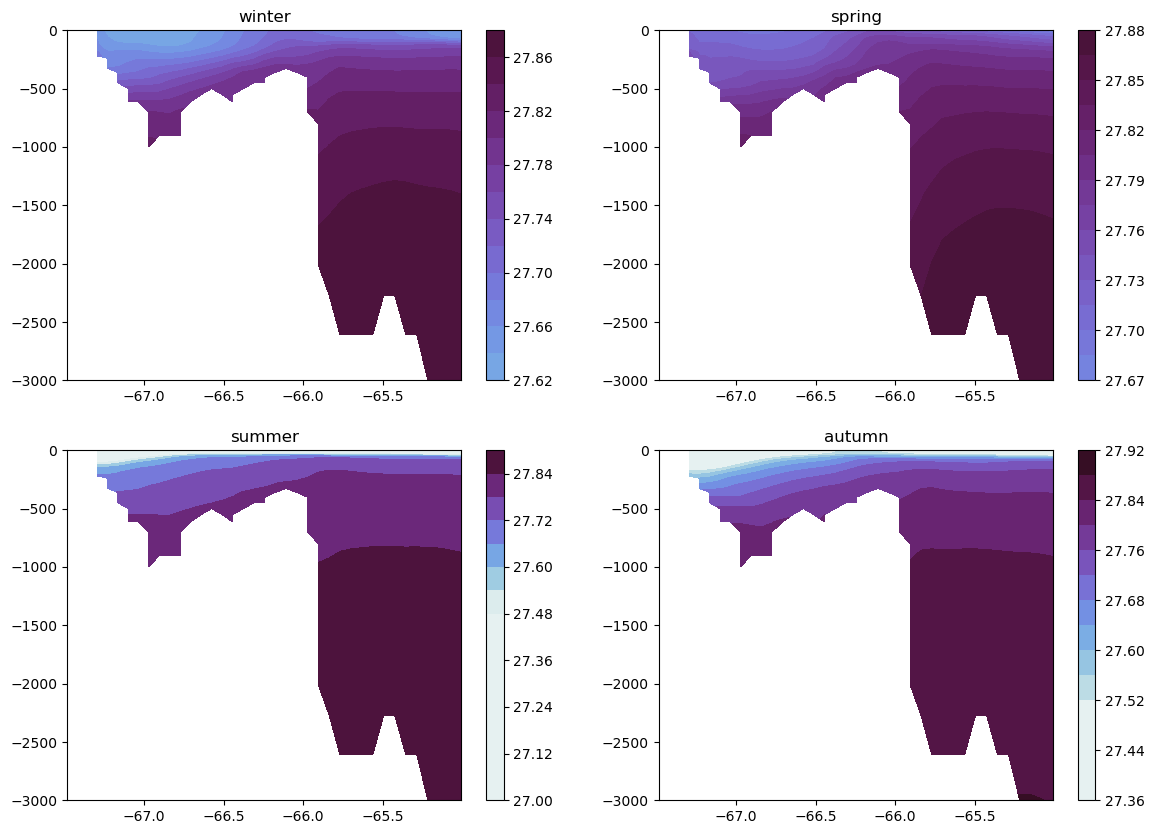

In [23]:
fig,axs = plt.subplots(2,2,figsize=(14,10))

def plotit(ax,s):
    im=ax.contourf(ds.YC,ds.Z,dss[s].mean('time'),vmax=27.9,vmin=27.5,levels=15,cmap=cmocean.cm.dense)
    ax.set_ylim([-3000,0])
    ax.set_title(s)
    plt.colorbar(im)

plotit(axs[0][0],'winter')
plotit(axs[0][1],'spring')
plotit(axs[1][0],'summer')
plotit(axs[1][1],'autumn')



In [ ]:
fig,axs = plt.subplots(2,2,figsize=(14,10))
dss = fns.season_split(ds.THETA)
def plotit(ax,s):
    im=ax.contourf(ds.YC,ds.Z,dss[s].mean('time'),vmax=1,vmin=-1.5,levels=15,cmap=cmocean.cm.dense)
    ax.set_ylim([-3000,0])
    ax.set_title(s)
    plt.colorbar(im)

plotit(axs[0][0],'winter')
plotit(axs[0][1],'spring')
plotit(axs[1][0],'summer')
plotit(axs[1][1],'autumn')

In [ ]:
#LABEL water masstypes
ds['wmt'] = ds.sigma0 * np.nan

In [ ]:
ds['wmt'].where((ds.sigma0 > 27.7) & ,'mCDW')